# Phase 6: Linear Probing — Regex Structure Across Layers

**Goal**: Probe frozen model activations at 5 layers to measure when and how
well each model (NTP vs STP) linearly encodes structural properties of the
target regex.

**Probe position**: The `\n\n` token immediately before regex generation begins
(second `<|eot_id|>` + 4). At this point the model has processed the full NL
description and the assistant-turn header — its "generation plan" lives here.

**What's new vs Phase 4B**: Phase 4B showed the STP-NTP *divergence* is in
regex-related directions. Probing asks: does STP also represent regex structure
*more strongly* in absolute terms, and does it appear earlier in the network?

**Probe targets** (6 binary features from the target regex):
- `has_alternation`: `|` present
- `has_negation`: `~` present (custom operator)
- `has_and`: `&` present (custom operator)
- `has_boundary`: `\\b` present
- `nesting_ge2`: max parenthesis depth >= 2
- `num_quant_ge2`: 2+ quantifiers

In [1]:
from phase6_probing import (
    extract_labels,
    label_balance_report,
    collect_all_probe_activations,
    run_probing_sweep,
    compute_all_deltas,
    plot_probing_curves,
    plot_delta_heatmap,
    print_probe_report,
    PROBE_LAYERS,
    PROBE_TARGETS,
)
from phase4b_subspace import load_chat_texts
from transformers import AutoTokenizer

MODELS = {
    "NTP": "/home/jay/repos/llm-jepa/output-exp1-regular",
    "STP": "/home/jay/repos/llm-jepa/output-exp1-stp",
}
TRAIN_FILE = "../datasets/synth_train.jsonl"
TEST_FILE  = "../datasets/synth_test.jsonl"
LAYERS     = PROBE_LAYERS   # [0, 3, 7, 11, 15]
BATCH_SIZE = 8
SEQ_LEN    = 128

## Extract Labels

In [2]:
labels_train = extract_labels(TRAIN_FILE)
labels_test  = extract_labels(TEST_FILE)

label_balance_report(labels_train, "train")
label_balance_report(labels_test,  "test")


Label Balance Report — train
-------------------------------------------------------
  Target                    Pos    Neg   Ratio  Warning
-------------------------------------------------------
  has_alternation          2878   5122   0.360
  has_negation             1384   6616   0.173
  has_and                  2172   5828   0.272
  has_boundary             1488   6512   0.186
  nesting_ge2              5699   2301   0.712
  num_quant_ge2            5901   2099   0.738
  Total examples: 8000

Label Balance Report — test
-------------------------------------------------------
  Target                    Pos    Neg   Ratio  Warning
-------------------------------------------------------
  has_alternation           701   1299   0.350
  has_negation              332   1668   0.166
  has_and                   555   1445   0.278
  has_boundary              408   1592   0.204
  nesting_ge2              1420    580   0.710
  num_quant_ge2            1448    552   0.724
  Total examples: 

## Load Texts

Chat template is applied so each text matches what the model was trained on.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct")
tokenizer.pad_token = tokenizer.eos_token

train_texts, _ = load_chat_texts(TRAIN_FILE, tokenizer)
test_texts,  _ = load_chat_texts(TEST_FILE,  tokenizer)
print(f"Train: {len(train_texts)} examples")
print(f"Test:  {len(test_texts)} examples")

Train: 8000 examples
Test:  2000 examples


## Collect Activations

For each model, load once and collect activations at the probe position
(\n\n before generation) across all 5 layers in a single forward pass per batch.

Each model produces two arrays per layer: `(8000, 2048)` for train, `(2000, 2048)` for test.

In [4]:
print("=== NTP ===")
ntp_train_acts, ntp_test_acts = collect_all_probe_activations(
    MODELS["NTP"], train_texts, test_texts,
    layers=LAYERS, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
)

=== NTP ===
  Loading model from /home/jay/repos/llm-jepa/output-exp1-regular
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Layer  0: train=(8000, 2048), test=(2000, 2048)
  Layer  3: train=(8000, 2048), test=(2000, 2048)
  Layer  7: train=(8000, 2048), test=(2000, 2048)
  Layer 11: train=(8000, 2048), test=(2000, 2048)
  Layer 15: train=(8000, 2048), test=(2000, 2048)


In [5]:
print("=== STP ===")
stp_train_acts, stp_test_acts = collect_all_probe_activations(
    MODELS["STP"], train_texts, test_texts,
    layers=LAYERS, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
)

=== STP ===
  Loading model from /home/jay/repos/llm-jepa/output-exp1-stp
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Layer  0: train=(8000, 2048), test=(2000, 2048)
  Layer  3: train=(8000, 2048), test=(2000, 2048)
  Layer  7: train=(8000, 2048), test=(2000, 2048)
  Layer 11: train=(8000, 2048), test=(2000, 2048)
  Layer 15: train=(8000, 2048), test=(2000, 2048)


## Run Probes

For each (model, layer, target) combination, train a logistic regression probe
on the train activations and evaluate on test.

5 layers × 6 targets = 30 probes per model.

In [6]:
print("=== NTP probes ===")
results_ntp = run_probing_sweep(
    ntp_train_acts, labels_train,
    ntp_test_acts,  labels_test,
    layers=LAYERS, targets=PROBE_TARGETS,
)

=== NTP probes ===
  layer= 0  has_alternation         AUROC=0.822  bal_acc=0.742
  layer= 0  has_negation            AUROC=0.924  bal_acc=0.853
  layer= 0  has_and                 AUROC=0.809  bal_acc=0.721
  layer= 0  has_boundary            AUROC=1.000  bal_acc=1.000
  layer= 0  nesting_ge2             AUROC=0.835  bal_acc=0.746
  layer= 0  num_quant_ge2           AUROC=0.868  bal_acc=0.801
  layer= 3  has_alternation         AUROC=1.000  bal_acc=0.996
  layer= 3  has_negation            AUROC=1.000  bal_acc=0.997
  layer= 3  has_and                 AUROC=1.000  bal_acc=0.988
  layer= 3  has_boundary            AUROC=1.000  bal_acc=1.000
  layer= 3  nesting_ge2             AUROC=0.994  bal_acc=0.959
  layer= 3  num_quant_ge2           AUROC=0.992  bal_acc=0.958
  layer= 7  has_alternation         AUROC=1.000  bal_acc=0.998
  layer= 7  has_negation            AUROC=1.000  bal_acc=1.000
  layer= 7  has_and                 AUROC=1.000  bal_acc=0.997
  layer= 7  has_boundary            

In [7]:
print("=== STP probes ===")
results_stp = run_probing_sweep(
    stp_train_acts, labels_train,
    stp_test_acts,  labels_test,
    layers=LAYERS, targets=PROBE_TARGETS,
)

=== STP probes ===
  layer= 0  has_alternation         AUROC=0.818  bal_acc=0.739
  layer= 0  has_negation            AUROC=0.926  bal_acc=0.855
  layer= 0  has_and                 AUROC=0.805  bal_acc=0.723
  layer= 0  has_boundary            AUROC=1.000  bal_acc=1.000
  layer= 0  nesting_ge2             AUROC=0.834  bal_acc=0.744
  layer= 0  num_quant_ge2           AUROC=0.871  bal_acc=0.807
  layer= 3  has_alternation         AUROC=1.000  bal_acc=0.997
  layer= 3  has_negation            AUROC=1.000  bal_acc=0.997
  layer= 3  has_and                 AUROC=1.000  bal_acc=0.987
  layer= 3  has_boundary            AUROC=1.000  bal_acc=1.000
  layer= 3  nesting_ge2             AUROC=0.994  bal_acc=0.962
  layer= 3  num_quant_ge2           AUROC=0.992  bal_acc=0.953
  layer= 7  has_alternation         AUROC=1.000  bal_acc=0.998
  layer= 7  has_negation            AUROC=1.000  bal_acc=1.000
  layer= 7  has_and                 AUROC=1.000  bal_acc=0.999
  layer= 7  has_boundary            

## Results: Probing Curves

AUROC vs layer for each probe target. Shaded regions are bootstrap 95% CIs.
Dashed line at 0.5 = chance. Points above chance = model linearly encodes that feature.

Saved: phase6_probing_curves.png


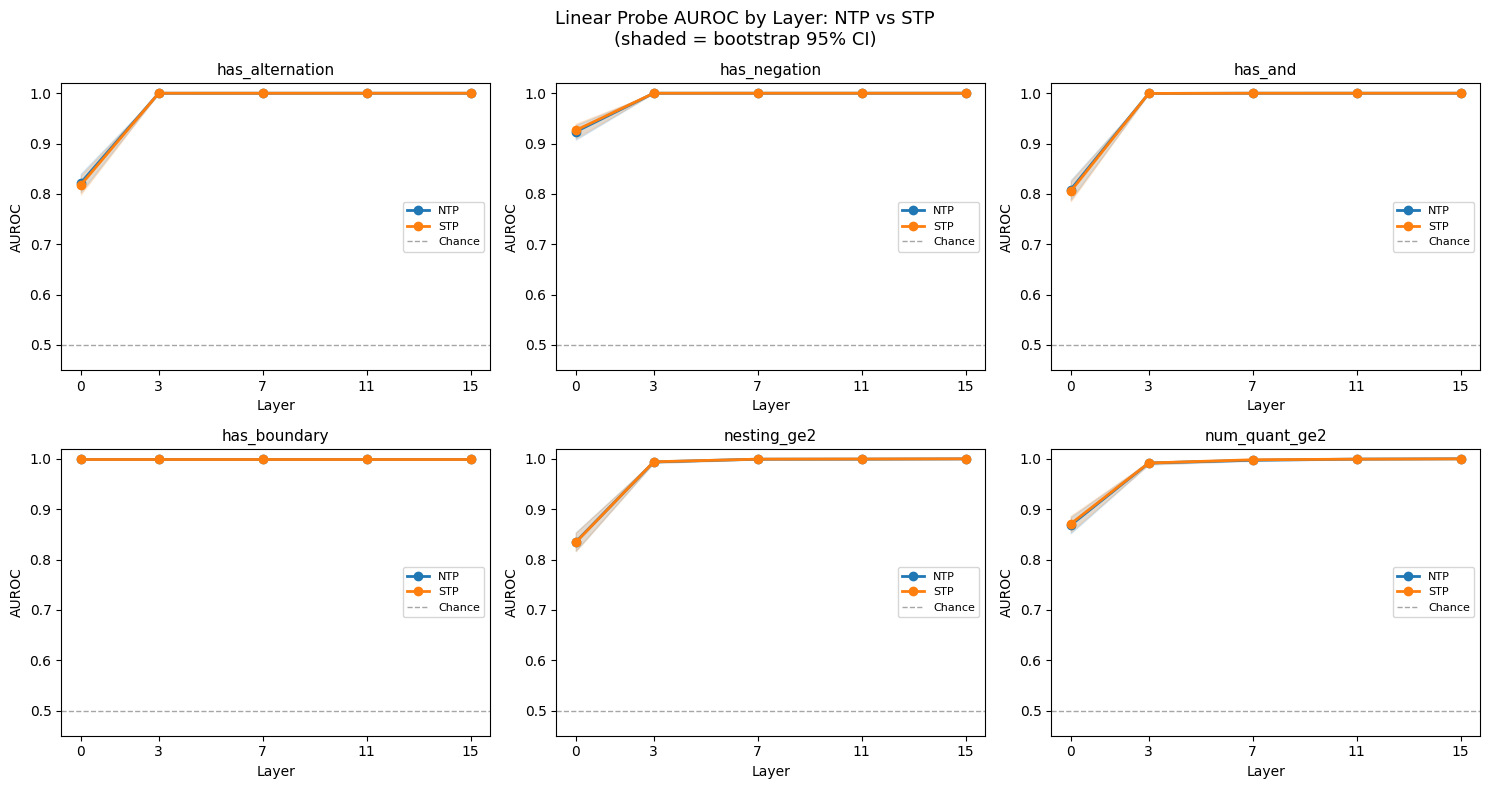

In [8]:
plot_probing_curves(
    results_ntp, results_stp, labels_test,
    metric="auroc",
    targets=PROBE_TARGETS,
    layers=LAYERS,
    n_bootstrap=500,
    save_path="phase6_probing_curves.png",
)

## NTP vs STP Difference

Paired bootstrap on the AUROC difference (STP − NTP) at each (layer, target).
Stars (*) indicate the 95% CI excludes zero.

In [9]:
print("Computing paired bootstrap deltas (this takes ~1 min)...")
deltas_df = compute_all_deltas(
    results_ntp, results_stp, labels_test,
    targets=PROBE_TARGETS, layers=LAYERS, n_bootstrap=1000,
)
print("Done.")

Computing paired bootstrap deltas (this takes ~1 min)...
Done.


Saved: phase6_delta_heatmap.png


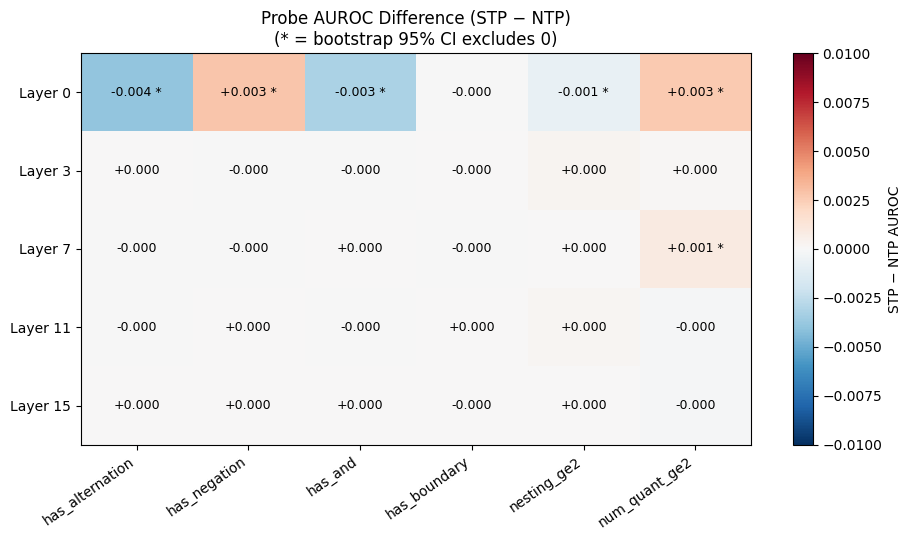

In [10]:
plot_delta_heatmap(
    deltas_df,
    targets=PROBE_TARGETS,
    layers=LAYERS,
    save_path="phase6_delta_heatmap.png",
)

In [11]:
print_probe_report(results_ntp, results_stp, deltas_df)


Linear Probing Report — NTP vs STP
  Metric: AUROC (primary), Balanced Accuracy (secondary)
  Layers: [0, 3, 7, 11, 15]

  has_alternation
    Layer   NTP AUROC   STP AUROC     Delta   Sig
  -------  ----------  ----------  --------  ----
        0       0.822       0.818    -0.004 *
        3       1.000       1.000    +0.000
        7       1.000       1.000    -0.000
       11       1.000       1.000    -0.000
       15       1.000       1.000    +0.000

  has_negation
    Layer   NTP AUROC   STP AUROC     Delta   Sig
  -------  ----------  ----------  --------  ----
        0       0.924       0.926    +0.003 *
        3       1.000       1.000    +0.000
        7       1.000       1.000    +0.000
       11       1.000       1.000    +0.000
       15       1.000       1.000    +0.000

  has_and
    Layer   NTP AUROC   STP AUROC     Delta   Sig
  -------  ----------  ----------  --------  ----
        0       0.809       0.805    -0.003 *
        3       1.000       1.000    -0.000

## Interpretation

Key things to look for:

1. **Layer 0**: Both models should be identical (shared embeddings). Any above-chance
   AUROC reflects lexical correlations in the NL description (e.g., "not" predicts
   `has_negation`). This is baseline — not compression learning.

2. **Layer curve shape**: Does probe AUROC rise monotonically? Does it plateau early
   (feature is lexically predictable) or keep rising (requires compositional processing)?

3. **STP vs NTP gap**: If STP is consistently higher at layers 11-15, it corroborates
   Phase 4B: the representational divergence reflects genuinely stronger regex encoding,
   not just a different coordinate system for the same information.

4. **Custom operators** (`has_and`, `has_negation`): These are domain-specific operators
   (`&`, `~`) not present in standard NL. Higher probing accuracy here would suggest
   STP learns richer representations of this synthetic language's semantics.